Today's topics:
* the shape of a distribution
* percentiles and the interquartile range
* histograms

# Solar cell efficiency loss

Perovskite solar cells convert light into electricity.

We measure their performance with the power-conversion efficiency (PCE): the percentage
of incoming light power converted to electrical power.

<img src="https://upload.wikimedia.org/wikipedia/commons/7/73/Perovskite_photovoltaics_efficiency_chart_2022.png" alt="NREL chart of record perovskite cell efficiencies over time against other PV technologies" width=560/>

(Record research-cell efficiencies over time. National Renewable Energy Laboratory, [Wikimedia Commons](https://commons.wikimedia.org/wiki/File:Perovskite_photovoltaics_efficiency_chart_2022.png), public domain.)

Efficiency can decrease during use. Let's look at how much these cells lost during
150 hours of laboratory ageing.

Between 2019 and 2022, researchers at Helmholtz-Zentrum Berlin collected ageing
traces for 2245 perovskite cells under one-sun illumination.

The cells had different designs, and test temperatures, atmospheres, and UV filtering
varied. We'll describe this collection of experiments.

<img src="https://media.springernature.com/lw685/springer-static/image/art%3A10.1038%2Fs41467-023-40585-3/MediaObjects/41467_2023_40585_Fig1_HTML.png" alt="Two ageing traces marked with maximum PCE and PCE at 150 hours, and violin plots of relative PCE loss by efficiency group, from Hartono et al. 2023" width=620/>

(Fig. 1 of [Hartono et al., *Nature Communications* 14, 4869 (2023)](https://doi.org/10.1038/s41467-023-40585-3), [CC BY 4.0](https://creativecommons.org/licenses/by/4.0/).)

Panel (a) quantifies the two numbers we'll keep per cell:
- `peak_pce` is the best efficiency the cell reached. 
- `pce_loss` is the share of that peak it had lost by 150 hours.

For example, a decrease from 20% efficiency to 12% is an 8 percentage-point drop,
or a loss of 40% of the peak efficiency.

We keep 2232 cells with peak efficiency at least 1%. Our summaries apply to that
subset; the other 13 cells are excluded (they are clear outliers -- more on that later).

Panel (b) is their summary of the loss, drawn with medians and interquartile ranges,
which are the two ideas we build today.

Let's look at the loss first, sorted, as we did last time:

In [1]:
#@title Load the perovskite ageing dataset (click ▶ to run, data loading, not a learning objective) { display-mode: "form" }
import os

import numpy as np
import pandas as pd

_file = 'perovskite_pv_aging.csv'
_github = f'https://raw.githubusercontent.com/wfreinhart/matse219/main/datasets/{_file}'
_local = next(
    (p for p in (f'datasets/{_file}', f'../datasets/{_file}', f'../../datasets/{_file}',
                 f'../../../datasets/{_file}')
     if os.path.exists(p)),
    None,
)

try:
    _table = pd.read_csv(_local if _local else _github)
except Exception as e:
    raise RuntimeError(
        f"Could not load '{_file}'. If you are in Colab, check your internet "
        f"connection and that the file exists at {_github}"
    ) from e

_alive = _table[_table['pce_max'] >= 1.0]

peak_pce = _alive['pce_max'].to_numpy()
pce_loss = (100.0 * (_alive['pce_max'] - _alive['final_pce']) / _alive['pce_max']).to_numpy()

print(f'Loaded {len(_table)} perovskite solar cells from {_file}')
print(f'  {len(_table) - len(_alive)} cells never reached 1% efficiency and are left out')
print(f'  peak_pce: {len(peak_pce)} values (%, best efficiency during the 150 h test)')
print(f'  pce_loss: {len(pce_loss)} values (%, share of that peak lost by the end)')

Loaded 2245 perovskite solar cells from perovskite_pv_aging.csv
  13 cells never reached 1% efficiency and are left out
  peak_pce: 2232 values (%, best efficiency during the 150 h test)
  pce_loss: 2232 values (%, share of that peak lost by the end)


In [2]:
import numpy as np

print(np.sort(pce_loss)[:5])
print(np.sort(pce_loss)[-5:])

[0.18126446 0.18607495 0.1980645  0.21603184 0.22537223]
[100. 100. 100. 100. 100.]


A few cells lost almost no efficiency, and a few totally degraded. Most were in between.

In [3]:
print(f'mean:   {np.mean(pce_loss):.1f}%')
print(f'median: {np.median(pce_loss):.1f}%')

mean:   28.8%
median: 23.5%


The mean sits well above the median. In L05 that gap was our first clue about the shape.

Here we will can look at the shape using a new tool: *histograms*.

# Histograms

Last time the histogram was hidden in a collapsed cell. Here's a simple recipe:

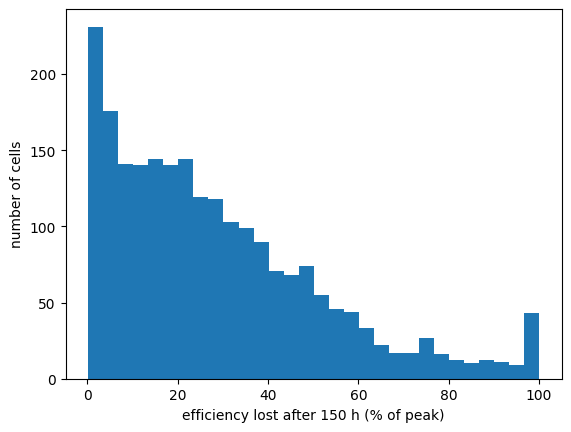

In [4]:
import matplotlib.pyplot as plt

plt.hist(pce_loss, bins=30)
plt.xlabel('efficiency lost after 150 h (% of peak)')
plt.ylabel('number of cells')
plt.show()

Here `plt.hist` sorts the values into `bins` equal-width intervals and draws one bar per
interval. The height of each bar is the count of cells that fall in it.

> This is a recipe to copy, not syntax to memorize. We'll take matplotlib apart properly
> in a later lecture!

Each square is one cell. The bars stand on equal-width bins of the value, and a bar's
height is how many cells fell in that bin.

This one is lopsided. Most cells lost a quarter or less, and a long tail extends to
the right, all the way to the cells that totally degraded.

## Bins

Note that `bins` is a resolution setting. Let's try a coarse one:

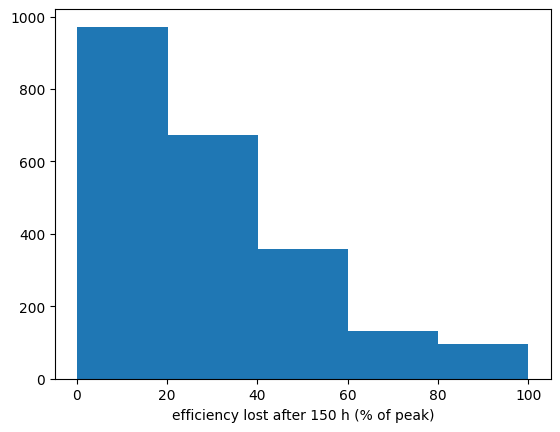

In [5]:
plt.hist(pce_loss, bins=5)
plt.xlabel('efficiency lost after 150 h (% of peak)')
plt.show()

Five bins hide the shape. Now a fine one:

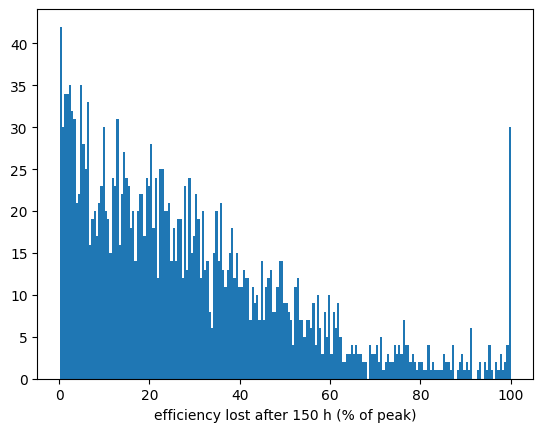

In [6]:
plt.hist(pce_loss, bins=200)
plt.xlabel('efficiency lost after 150 h (% of peak)')
plt.show()

Hundreds of bins make it too noisy. For thousands of values, something like 30
to 50 bins works, and the tail is visible no matter what.
> The rule of thumb is something like sqrt(n) bins, where n is the number of values. For 2232 cells, about 45-50.

## The other array

Same recipe, swapping in the peak efficiency:

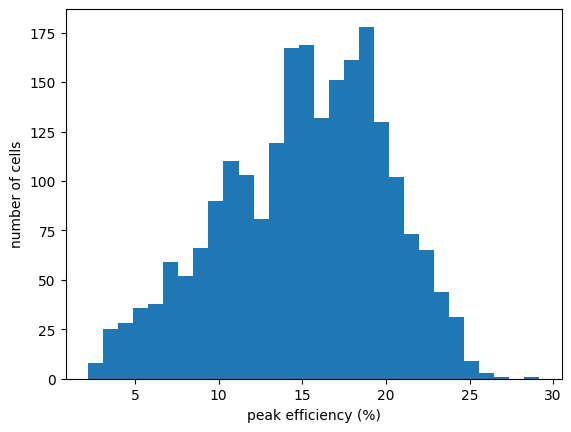

In [7]:
plt.hist(peak_pce, bins=30)
plt.xlabel('peak efficiency (%)')
plt.ylabel('number of cells')
plt.show()

This one is a hump around 15% with tails of similar length on each side.

We call the shape on the left **symmetric**: the two tails match and the mean sits on
the median. That's roughly our peak efficiency.

The shape on the right is **right-skewed**: a long tail toward high values, with the
mean pulled out along it, past the median. That's our loss.

Let's check the symmetric claim the same way we checked the loss:

In [8]:
print(f'mean:   {np.mean(peak_pce):.1f}%')
print(f'median: {np.median(peak_pce):.1f}%')

mean:   15.1%
median: 15.4%


For the peak efficiency the two are close. The gap is much larger for the loss.

# Percentiles: where a value sits

The median is the value with half the data below it. A **percentile** generalizes that
idea: the 25th percentile has a quarter of the data below it, the 90th has nine tenths.

In NumPy this is `np.percentile`, which takes the array and a level between 0 and 100.
Let's start with 50, which we already know:

In [9]:
print(np.percentile(pce_loss, 50))
print(np.median(pce_loss))

23.480884854184502
23.480884854184502


Same number! Now the quartiles, the 25th and 75th percentiles:

In [10]:
q1 = np.percentile(pce_loss, 25)
q3 = np.percentile(pce_loss, 75)
print(f'Q1 = {q1:.1f}%')
print(f'Q3 = {q3:.1f}%')

Q1 = 10.5%
Q3 = 41.3%


So the middle half of the cells lost somewhere between a tenth and two fifths of their
peak.

We can pass an array of levels too, and then the result is an array in the same order:

In [11]:
levels = np.array([10, 25, 50, 75, 90])
print(np.percentile(pce_loss, levels))

[ 3.42616158 10.45722097 23.48088485 41.26072446 60.70221885]


Read this with the histogram in mind. The 10th percentile is close to the median and
the 90th is far from it, and that asymmetry *is* the right skew or tail.

### [Check your understanding]

Now let's use the same tools on `peak_pce`, where higher efficiency is better.

1. Plot a histogram of `peak_pce` using the recipe above. Describe its shape.
2. Print the 10th, 50th, and 90th percentiles in one call. What does their spacing tell you?
3. Find the cutoff for the highest-efficiency quarter of these cells. Which
   percentile do we need, and what are the units of the result?

*Think: when might you want to use percentile, and when might you use indexing?*


What about the ends?

In [12]:
print(np.percentile(pce_loss, 0), np.min(pce_loss))
print(np.percentile(pce_loss, 100), np.max(pce_loss))

0.18126445690848456 0.18126445690848456
100.00000000000001 100.00000000000001


So the 0th percentile is the minimum and the 100th is the maximum.

> When a level falls between two data points the function interpolates, so a percentile
> need not be a value that actually appears in the array.

## The interquartile range

Last time we measured spread with the standard deviation. Now the quartiles give us
another measure:

$$\text{IQR} = Q_3 - Q_1$$

Here:
* $Q_1$ is the 25th percentile
* $Q_3$ is the 75th percentile
* so the IQR is the width of the middle half of the data

In [13]:
iqr = q3 - q1
print(f'IQR of relative loss: {iqr:.1f} percentage points')

IQR of relative loss: 30.8 percentage points


Moving the largest value farther out leaves the quartiles unchanged, as long as
its rank stays above the values used to compute Q3. The standard deviation changes.

We call the IQR **robust** [less sensitive to extreme values]. Adding or removing
observations can still change the quartile positions and the IQR.

Let's compute it for the peak efficiency too:

In [14]:
peak_iqr = np.percentile(peak_pce, 75) - np.percentile(peak_pce, 25)
print(f'peak-efficiency IQR: {peak_iqr:.1f} percentage points')

peak-efficiency IQR: 7.1 percentage points


This is the width of the middle half of the peak efficiencies we plotted.

# The upper tail of the loss

What loss did nine out of ten of the retained cells stay below after 150 hours?

We need the 90th percentile:

In [15]:
print(f'{np.percentile(pce_loss, 90):.0f}%')

61%


About nine in ten of these cells lost no more than 61% of their peak efficiency.

Compare that with the mean:

In [16]:
print(f'{np.mean(pce_loss):.0f}%')

29%


The mean loss is roughly half that cutoff. It describes the average loss, rather
than a threshold containing nine tenths of the observations.

To make a guarantee for a particular product, we'd need representative tests of
that product under specified conditions and an allowance for sampling uncertainty.

## A number for the skew

So far we've been reading the skew off the histogram and off the gap between mean and
median. SciPy will put a number on it.

You don't need to learn this, it's just worth knowing it exists:

In [17]:
#@title Optional tool glimpse: scipy.stats.skew (click ▶ to run) { display-mode: "form" }
from scipy.stats import skew

print(f'peak efficiency: {skew(peak_pce):.2f}')
print(f'efficiency lost: {skew(pce_loss):.2f}')

peak efficiency: -0.32
efficiency lost: 1.07


Positive skewness is consistent with a longer right tail; negative skewness with a
longer left tail. Zero alone doesn't establish symmetry, so keep the histogram in view.

The efficiency is slightly left-skewed; the loss is strongly right-skewed.

# Describing the loss

For the cells we retained, the median loss describes the middle observation.
The 90th percentile describes how far up the loss distribution we go to include
nine out of ten observations.

So our description of a distribution now has three parts: a center (mean or median),
a spread (standard deviation or IQR), and a *shape*, which the histogram shows and the
percentiles measure.

Quiz warm-up


## Further reading

- [VanderPlas: Aggregations (min, max, and everything in between)](https://jakevdp.github.io/PythonDataScienceHandbook/02.04-computation-on-arrays-aggregates.html)
- [VanderPlas: Histograms and binnings](https://jakevdp.github.io/PythonDataScienceHandbook/04.05-histograms-and-binnings.html)
- [NumPy documentation: `np.percentile`](https://numpy.org/doc/stable/reference/generated/numpy.percentile.html)
- [Hartono et al. (2023), the paper behind today's data](https://doi.org/10.1038/s41467-023-40585-3)